In [197]:
"""
Omniprediction Experiment: Validating the Omniprediction Guarantee

Goal: Demonstrate that the omniprediction predictor P achieves low regret
uniformly over all scoring functions in the class S_alpha, matching the
theoretical guarantee:

    sup_{S in S_alpha, f in C} E[S(P(X), Y)] - E[S(f(X), Y)] <= O(sqrt(log m |C| / T))

Key insight: The omniprediction algorithm learns a predictor distribution P
that performs well against ALL possible quantile scoring functions simultaneously,
not just a single target quantile.
"""

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from typing import List, Callable, Tuple


# ============================================================================
# Elementary Quantile Scoring Functions
# ============================================================================


def elementary_score_quantile(
    p, y, theta: float, alpha: float = 0.5
):
    r"""
    Elementary quantile scoring function for alpha-level quantile.

    S_{alpha, theta}(p, y) = (1{y < p} - alpha) * (1{theta < p} - 1{theta < y})

    Supports scalar float input, or p and y as equal-length np.ndarray.

    Parameters
    ----------
    p : float or array-like
        Predicted quantile level(s) (in [0, 1])
    y : float or array-like
        True observation(s) (in [0, 1])
    theta : float
        Threshold parameter (float)
    alpha : float
        Quantile level (0.5 = median)

    Returns
    -------
    score : float or np.ndarray
        Score value(s)
    """
    p_arr = np.asarray(p)
    y_arr = np.asarray(y)
    # Handle same shape or broadcast error if needed
    if p_arr.shape != y_arr.shape:
        raise ValueError("p and y must have the same shape.")
    # Term 1: (1{y < p} - alpha)
    term1 = (y_arr < p_arr).astype(float) - alpha
    # Term 2: (1{theta < p} - 1{theta < y})
    term2 = (theta < p_arr).astype(float) - (theta < y_arr).astype(float)
    
    out = term1 * term2
    if p_arr.shape == y_arr.shape and len(p_arr.shape) == 1 and p_arr.shape[0] > 1:
        return np.mean(out)
    else:
        return out

def pinball_loss(p, y, alpha):
    return (y - p) * (y > p) * alpha + (p - y) * (y <= p) * (1-alpha)


def create_scoring_function_class(alpha: float, m: int) -> Tuple[List[Callable], np.ndarray]:
    """
    Create the class S_alpha of elementary scoring functions.
    
    Parameters
    ----------
    alpha : float
        Quantile level (e.g., 0.5 for median)
    m : int
        Number of discretized theta values
    
    Returns
    -------
    scoring_functions : list
        List of scoring functions S_{alpha, theta_i}
    thetas : np.ndarray
        Discretized theta values: theta_i = 1/(2m) + i/m
    """
    # Discretize theta as theta_i = 1/(2m) + i/m
    thetas = 1.0 / (2 * m) + np.arange(m) / m
    
    def make_scoring_function(theta, alpha):
        """Create scoring function for specific theta and alpha."""
        return lambda p, y: elementary_score_quantile(p, y, theta, alpha)
    
    scoring_functions = [
        make_scoring_function(theta, alpha) for theta in thetas
    ]
    
    return scoring_functions, thetas


# ============================================================================
# Base Forecast Class
# ============================================================================

def create_base_forecaster_class(F: int, seed: int = 42) -> Tuple[List[Callable], List[str]]:
    """
    Create a class of base forecaster functions C = {f_1, ..., f_F}.
    
    These are different quantile predictors that will compete.
    
    Parameters
    ----------
    F : int
        Number of base forecasters
    seed : int
        Random seed
    
    Returns
    -------
    forecasters : list
        List of forecaster functions
    names : list
        Names of forecasters
    """
    np.random.seed(seed)
    forecasters = []
    names = []
    
    # Forecaster 1: Biased low (predicts low quantiles)
    forecasters.append(lambda x: np.clip(0.3 + 0.1 * x, 0, 1))
    names.append("Biased Low")
    
    # Forecasters 2-3: Random linear models
    for i in range(2):
        w = np.random.randn()
        b = np.random.uniform(0.2, 0.8)
        forecasters.append(lambda x, w=w, b=b: np.clip(b + w * x, 0, 1))
        names.append(f"Random {i+1}")
    
    # Forecasters 4-5: Quantile estimators at fixed levels
    forecasters.append(lambda x: np.clip(np.median(x) + 0.2, 0, 1))  # Higher quantile
    names.append("High Quantile")
    
    forecasters.append(lambda x: np.clip(np.median(x) - 0.2, 0, 1))  # Lower quantile
    names.append("Low Quantile")
    
    return forecasters, names


# ============================================================================
# Data Generation
# ============================================================================

def generate_quantile_data(n: int, m: int, seed: int = 42) -> Tuple[np.ndarray, np.ndarray]:
    """
    Generate synthetic data where Y is the quantile of a mixture distribution.
    
    Parameters
    ----------
    n : int
        Number of samples
    m : int
        Number of discretized theta values
    seed : int
        Random seed
    
    Returns
    -------
    X : np.ndarray
        Shape (n,) - input features in [0, 1]
    Y : np.ndarray
        Shape (n,) - observations in [0, 1] representing quantiles
    """
    np.random.seed(seed)
    
    X = np.random.uniform(0, 1, size=n)
    
    # True conditional distribution: Y depends on X
    true_mean = 0.2 + 0.6 * X
    
    # Add noise and clip to [0, 1]
    noise = np.random.normal(0, 0.3, size=n)
    Y = np.clip(true_mean + noise, 0, 1)
    
    # Discretize Y to {0, 1/m, 2/m, ..., 1} for cleaner experiment
    Y = np.round(Y * m) / m
    
    return X, Y


# ============================================================================
# Omniprediction Error Computation
# ============================================================================


def single_q_minmax_solver(
    theta_weights: np.ndarray,      # (m,)
    forecast_values: np.ndarray,    # (m,)
    thetas: np.ndarray,             # (m,)
    eq_value: float = 0.0,
    tol: float = 1e-8,
) -> dict:
    """
    Solve the minmax problem for a single quantile level.
    Contains randomness in the choice of phat.
    """
    m = len(thetas)
    assert len(theta_weights) == len(forecast_values) == len(thetas)
    assert np.isclose(np.sum(theta_weights), 1.0)
    weighted_weights = np.sum(theta_weights * (thetas < forecast_values).astype(float))
    Bk_pre = np.concatenate([[0], np.cumsum(theta_weights) - weighted_weights])    # [0 (placeholder), B_1, ..., B_m=0]
    k_star = np.searchsorted(Bk_pre, eq_value+tol, side='right') - 1   
    
    # phat is 1.0 with probability 1.0
    if k_star == m:
        return {
        "phat": 1.0,
        "k_star": k_star,
        "k_star_prob": 1.0,
    }

    assert not np.isclose(Bk_pre[k_star+1], eq_value, atol=tol)
    if np.isclose(Bk_pre[k_star], eq_value, atol=tol) or k_star == m:
        k_star_prob = 1.0
        phat = k_star / m
    else:
        k_star_prob = (Bk_pre[k_star+1])/(Bk_pre[k_star+1] - Bk_pre[k_star])
        try:
            phat = np.random.choice([k_star / m, (k_star+1) / m], p=[k_star_prob, 1.0-k_star_prob])
        except:
            print(k_star_prob)
            print(Bk_pre[k_star+1])
            print(Bk_pre[k_star])
            raise
    
    return {
        "phat": phat,
        "k_star": k_star,
        "k_star_prob": k_star_prob,
    }


def single_q_omnipred_error(
    predictions: np.ndarray,    # (T,)
    Y: np.ndarray,              # (T,)
    scoring_functions: List[Callable],  # (m,)
) -> float:
    """
    Compute the omniprediction error for given quantile prediction.
    """

    return np.array([S(predictions, Y) for S in scoring_functions])


# ============================================================================
# Main Omniprediction Experiment
# ============================================================================

def omniprediction_experiment(T: int = 500, m: int = 10, F: int = 5, 
                             alpha: float = 0.5, eta: float = 0.1,
                             eta_f: float = 0.1, seed: int = 42):
    """
    Run omniprediction experiment and compare against base forecasters.
    
    Parameters
    ----------
    T : int
        Time horizon / number of samples
    m : int
        Number of discretized theta values
    F : int
        Number of base forecasters
    alpha : float
        Quantile level
    eta : float
        Learning rate for weights w_i
    eta_f : float
        Learning rate for forecaster selection v_{i,j}
    seed : int
        Random seed
    
    Returns
    -------
    results : dict
        Dictionary containing all results
    """
    print("="*70)
    print("OMNIPREDICTION EXPERIMENT")
    print("="*70)
    
    np.random.seed(seed)
    
    # Setup
    print(f"\nSetup:")
    print(f"  Time horizon: T = {T}")
    print(f"  Quantile level: alpha = {alpha}")
    print(f"  Discretized thetas: m = {m}")
    print(f"  Base forecasters: F = {F}")
    
    # Generate data
    X, Y = generate_quantile_data(n=T, m=m, seed=seed)
    print(f"\nData:")
    print(f"  X range: [{X.min():.3f}, {X.max():.3f}]")
    print(f"  Y range: [{Y.min():.3f}, {Y.max():.3f}]")
    
    # Create scoring function class S_alpha
    scoring_functions, thetas = create_scoring_function_class(alpha, m)
    print(f"\nScoring functions S_{alpha}:")
    print(f"  Number of theta values: {m}")
    print(f"  Theta range: [{thetas.min():.3f}, {thetas.max():.3f}]")
    
    # Create base forecaster class
    forecasters, forecaster_names = create_base_forecaster_class(F, seed)
    print(f"\nBase forecasters C = {{f_1, ..., f_F}}:")
    for i, name in enumerate(forecaster_names):
        print(f"  {i+1}. {name}")
    
    # Initialize algorithm state
    w = np.ones(m) / m  # Uniform weights over thetas
    v = np.ones((m, F)) / F  # Uniform weights over forecasters for each theta
    pinball_v = np.ones(F) / F  
    f_selected = [forecasters[0]] * m  # Initially all use first forecaster
    pinball_f_selected = 0
    
    # Storage for regrets over time
    phat_history = np.zeros(T)
    w_history = np.zeros((T, m))
    v_history = np.zeros((T, m, F))
    omni_error_history = np.zeros((T, m))
    preds_history = np.zeros((T, F))
    forecasters_score_history = np.zeros((T, m, F))
    forecasters_selection_history = np.zeros((T, m))

    pinball_selection_history = np.zeros(T)
    pinball_preds_history = np.zeros(T)
    
    print(f"\nRunning omniprediction algorithm...")
    
    for t in tqdm(range(T)):
        x_t = X[t]
        y_t = Y[t]
        
        # Step 1: Compute P_t
        forecaster_preds = np.array([f(x_t) for f in f_selected])
        
        phat_dict = single_q_minmax_solver(
            theta_weights=w,
            forecast_values=forecaster_preds,
            thetas=thetas,
        )
        phat = phat_dict["phat"]
        phat_history[t] = phat
        k_star = phat_dict["k_star"]
        k_star_prob = phat_dict["k_star_prob"]
        
        # Step 2: Compute expected score under P_t
        phat_score = k_star_prob * np.array([S(k_star/m, y_t) for S in scoring_functions]) + \
            (1-k_star_prob) * np.array([S((k_star+1)/m, y_t) for S in scoring_functions])
        f_selected_score = np.array([S(forecaster_preds[i], y_t) for i, S in enumerate(scoring_functions)])
        
        # Step 3: Update weights w_i
        w_history[t,:] = w
        v_history[t,:,:] = v
        log_w = np.log(w + 1e-10)
        log_w += eta * (phat_score - f_selected_score)
        
        # Normalize in log space
        max_log_w = np.max(log_w)
        log_w -= max_log_w
        w = np.exp(log_w)
        w /= np.sum(w)
        
        # Step 4: Update forecaster selection v_{i,j} (vectorized implementation)
        # Compute all scores: scores[i, j] = S_i(f_j(x_t), y_t)
        preds = np.array([forecasters[j](x_t) for j in range(F)])
        preds_history[t,:] = preds
        scores = np.array([[scoring_functions[i](preds[j], y_t) for j in range(F)] for i in range(m)])
        
        log_v = np.log(v + 1e-10)
        log_v -= eta_f * scores
        
        # Normalize in log-space for numerical stability
        max_log_v = np.max(log_v, axis=1, keepdims=True)
        log_v -= max_log_v
        
        v = np.exp(log_v)
        v /= np.sum(v, axis=1, keepdims=True)
        
        # Step 4-2: Hedge algorithm using pinball loss
        pinball_selection_history[t] = pinball_f_selected
        pinball_preds_history[t] = preds[pinball_f_selected]

        pinball_losses = np.array([pinball_loss(preds[j], Y[t], alpha) for j in range(F)])
        pinball_v = np.log(pinball_v + 1e-10)
        pinball_v -= eta_f * pinball_losses
        pinball_v -= np.max(pinball_v, axis=0, keepdims=True)
        pinball_v = np.exp(pinball_v)
        pinball_v /= np.sum(pinball_v, axis=0, keepdims=True)
        pinball_f_selected = np.random.choice(F, p=pinball_v)

        

        # Step 5: Sample new forecasters
        j_i_arr = np.zeros(m)
        for i in range(m):
            j_i = np.random.choice(F, p=v[i,:])
            j_i_arr[i] = j_i
            f_selected[i] = forecasters[j_i]
        
        # Compute regret at time t
        forecasters_selection_history[t,:] = j_i_arr
        forecasters_score_history[t,:, :] = scores
        omni_error_history[t,:] = single_q_omnipred_error(
            predictions=phat,
            Y=Y[t],
            scoring_functions=scoring_functions,
        )
    
    print(f"\n" + "="*70)
    print("RESULTS")
    print("="*70)
    
    # print(f"\nOmniprediction error (from learned P):")
    # print(f"  sup_{{S in S_alpha}} E[S(P(X), Y)] = {omni_error:.6f}")
    
    # # Compute regret of each base forecaster
    # print(f"\nRegret of each base forecaster:")
    # print(f"  sup_{{S in S_alpha}} E[S(f_j(X), Y)]")
    
    omni_score_trace = np.max(omni_error_history.cumsum(axis=0), axis=1) / (np.arange(len(omni_error_history)) + 1)
    forecasters_score_cumulative = forecasters_score_history.cumsum(axis=0).max(axis=1) / (np.arange(len(forecasters_score_history))[:, None] + 1)
    best_forecaster_score_trace = forecasters_score_cumulative.min(axis=1)

    # best_regret = np.inf
    # for j, (f, name) in enumerate(zip(forecasters, forecaster_names)):
    #     regret, _ = compute_regret_against_forecaster(
    #         Y, f, scoring_functions, thetas
    #     )
    #     print(f"  {name:15s}: {regret:.6f}")
    #     best_regret = min(best_regret, regret)
    
    # print(f"\nBest base forecaster regret: {best_regret:.6f}")
    
    # # Omniprediction regret vs best forecaster
    # regret_gap = omni_error - best_regret
    # print(f"Omniprediction vs best forecaster:")
    # print(f"  Gap: {regret_gap:.6f}")
    # print(f"  Ratio: {omni_error / (best_regret + 1e-10):.4f}x")
    
    # Theoretical bound
    theoretical_bound = np.sqrt(np.log(m * F) / T)
    print(f"\nTheoretical omniprediction guarantee:")
    print(f"  O(sqrt(log(m*F)/T)) = O(sqrt({np.log(m*F):.2f}/{T}))")
    print(f"                      = O({theoretical_bound:.6f})")
    
    # Return results
    return {
        'phat_history': phat_history,
        'w_history': w_history,
        'v_history': v_history,
        'omni_error_history': omni_error_history,
        'omni_score_trace': omni_score_trace,
        'forecasters_preds_history': preds_history,
        'forecasters_score_history': forecasters_score_history,
        'forecasters_selection_history': forecasters_selection_history,
        'forecasters_score_cumulative': forecasters_score_cumulative,
        'best_forecaster_score_trace': best_forecaster_score_trace,
        'thetas': thetas,
        'pinball_selection_history': pinball_selection_history,
        'pinball_preds_history': pinball_preds_history,
        'Y': Y,
        'X': X,
        'T': T,
        'm': m,
        'F': F,
        'alpha': alpha,
        'forecaster_names': forecaster_names,
        'theoretical_bound': theoretical_bound,
    }


def simple_plot(results: dict):
    """Plot omniprediction experiment results."""
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    ax = axes[0,0]
    ax.plot(np.arange(results['T']), results['omni_score_trace'], label='Omniprediction error')
    ax.plot(np.arange(results['T']), results['best_forecaster_score_trace'], label='Best forecaster')
    ax.plot(np.arange(results['T']), [np.minimum(np.sqrt(np.log(results['m'] * results['F']) / t), 1.0) for t in np.arange(results['T'])], '--', label='Theoretical bound')
    ax.set_xlabel('Time t')
    ax.legend()

    return fig

# ============================================================================
# Visualization
# ============================================================================

def plot_omniprediction_results(results: dict):
    """Plot omniprediction experiment results."""
    
    fig, axes = plt.subplots(2, 2, figsize=(13, 10))
    
    # Plot 1: Error per theta
    ax = axes[0, 0]
    ax.bar(range(len(results['thetas'])), results['errors_per_theta'], 
           alpha=0.7, edgecolor='black', color='steelblue')
    ax.set_xlabel('Theta index i')
    ax.set_ylabel('Error for S_{α, θ_i}')
    ax.set_title(f'Error per Scoring Function\n(Max = {results["errors_per_theta"].max():.6f})')
    ax.grid(alpha=0.3)
    
    # Plot 2: Regret evolution over time
    ax = axes[0, 1]
    T = len(results['regret_evolution'])
    ax.plot(results['regret_evolution'], linewidth=2, alpha=0.7, label='Omniprediction error')
    
    # Add theoretical bound as reference
    cumulative_sqrt_bound = np.sqrt(np.log(11 * 5) / np.arange(1, T+1))
    ax.plot(cumulative_sqrt_bound, linestyle='--', linewidth=2, alpha=0.7, 
            label=f'Theoretical O(sqrt(log(mF)/t))')
    
    ax.set_xlabel('Time t')
    ax.set_ylabel('Max error across θ')
    ax.set_title('Omniprediction Error Evolution')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 3: Final distribution at select times
    ax = axes[1, 0]
    P_preds = results['P_predictions']
    times_to_plot = [T // 10, T // 2, T - 1]
    for t in times_to_plot:
        ax.plot(results['thetas'], P_preds[t], 'o-', label=f't={t+1}', alpha=0.7)
    ax.set_xlabel('Theta θ_i')
    ax.set_ylabel('Weight P_t(θ_i)')
    ax.set_title('Predicted Distribution at Different Times')
    ax.legend()
    ax.grid(alpha=0.3)
    
    # Plot 4: Summary comparison
    ax = axes[1, 1]
    categories = ['Omniprediction\nP', 'Best Base\nForecaster']
    values = [results['omni_error'], results['best_regret']]
    colors = ['steelblue', 'orange']
    
    bars = ax.bar(categories, values, alpha=0.7, edgecolor='black', color=colors, width=0.5)
    
    # Add value labels
    for bar, val in zip(bars, values):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{val:.6f}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')
    
    ax.axhline(results['theoretical_bound'], color='red', linestyle='--', 
               linewidth=2, label=f'Bound: {results["theoretical_bound"]:.6f}')
    ax.set_ylabel('Max Error across Scoring Functions')
    ax.set_title('Omniprediction vs Base Forecasters')
    ax.legend()
    ax.grid(alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('/mnt/user-data/outputs/omniprediction_guarantee.png', dpi=100, bbox_inches='tight')
    print("\nPlot saved: omniprediction_guarantee.png")
    plt.close()



In [198]:
# ============================================================================
# Run Experiment
# ============================================================================

T = 5000
m = 50
F = 5

results_dic = {}

for alpha in [0.1, 0.3, 0.5, 0.7,0.9]:
    results = omniprediction_experiment(T=T, m=m, F=F, alpha=alpha, eta=np.sqrt(np.log(m)/T), eta_f=np.sqrt(np.log(F)/T))
    results_dic[alpha] = results
    print("\n" + "="*70)
    print("Experiment complete!")
    print("="*70)

OMNIPREDICTION EXPERIMENT

Setup:
  Time horizon: T = 5000
  Quantile level: alpha = 0.1
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.000, 1.000]
  Y range: [0.000, 1.000]

Scoring functions S_0.1:
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Biased Low
  2. Random 1
  3. Random 2
  4. High Quantile
  5. Low Quantile

Running omniprediction algorithm...


100%|██████████| 5000/5000 [00:09<00:00, 507.24it/s]



RESULTS

Theoretical omniprediction guarantee:
  O(sqrt(log(m*F)/T)) = O(sqrt(5.52/5000))
                      = O(0.033231)

Experiment complete!
OMNIPREDICTION EXPERIMENT

Setup:
  Time horizon: T = 5000
  Quantile level: alpha = 0.3
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.000, 1.000]
  Y range: [0.000, 1.000]

Scoring functions S_0.3:
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Biased Low
  2. Random 1
  3. Random 2
  4. High Quantile
  5. Low Quantile

Running omniprediction algorithm...


100%|██████████| 5000/5000 [00:09<00:00, 514.46it/s]



RESULTS

Theoretical omniprediction guarantee:
  O(sqrt(log(m*F)/T)) = O(sqrt(5.52/5000))
                      = O(0.033231)

Experiment complete!
OMNIPREDICTION EXPERIMENT

Setup:
  Time horizon: T = 5000
  Quantile level: alpha = 0.5
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.000, 1.000]
  Y range: [0.000, 1.000]

Scoring functions S_0.5:
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Biased Low
  2. Random 1
  3. Random 2
  4. High Quantile
  5. Low Quantile

Running omniprediction algorithm...


...


RESULTS

Theoretical omniprediction guarantee:
  O(sqrt(log(m*F)/T)) = O(sqrt(5.52/5000))
                      = O(0.033231)

Experiment complete!
OMNIPREDICTION EXPERIMENT

Setup:
  Time horizon: T = 5000
  Quantile level: alpha = 0.7
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.000, 1.000]
  Y range: [0.000, 1.000]

Scoring functions S_0.7:
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Biased Low
  2. Random 1
  3. Random 2
  4. High Quantile
  5. Low Quantile

Running omniprediction algorithm...


100%|██████████| 5000/5000 [00:10<00:00, 498.85it/s]



RESULTS

Theoretical omniprediction guarantee:
  O(sqrt(log(m*F)/T)) = O(sqrt(5.52/5000))
                      = O(0.033231)

Experiment complete!
OMNIPREDICTION EXPERIMENT

Setup:
  Time horizon: T = 5000
  Quantile level: alpha = 0.9
  Discretized thetas: m = 50
  Base forecasters: F = 5

Data:
  X range: [0.000, 1.000]
  Y range: [0.000, 1.000]

Scoring functions S_0.9:
  Number of theta values: 50
  Theta range: [0.010, 0.990]

Base forecasters C = {f_1, ..., f_F}:
  1. Biased Low
  2. Random 1
  3. Random 2
  4. High Quantile
  5. Low Quantile

Running omniprediction algorithm...


100%|██████████| 5000/5000 [00:09<00:00, 529.41it/s]


RESULTS

Theoretical omniprediction guarantee:
  O(sqrt(log(m*F)/T)) = O(sqrt(5.52/5000))
                      = O(0.033231)

Experiment complete!


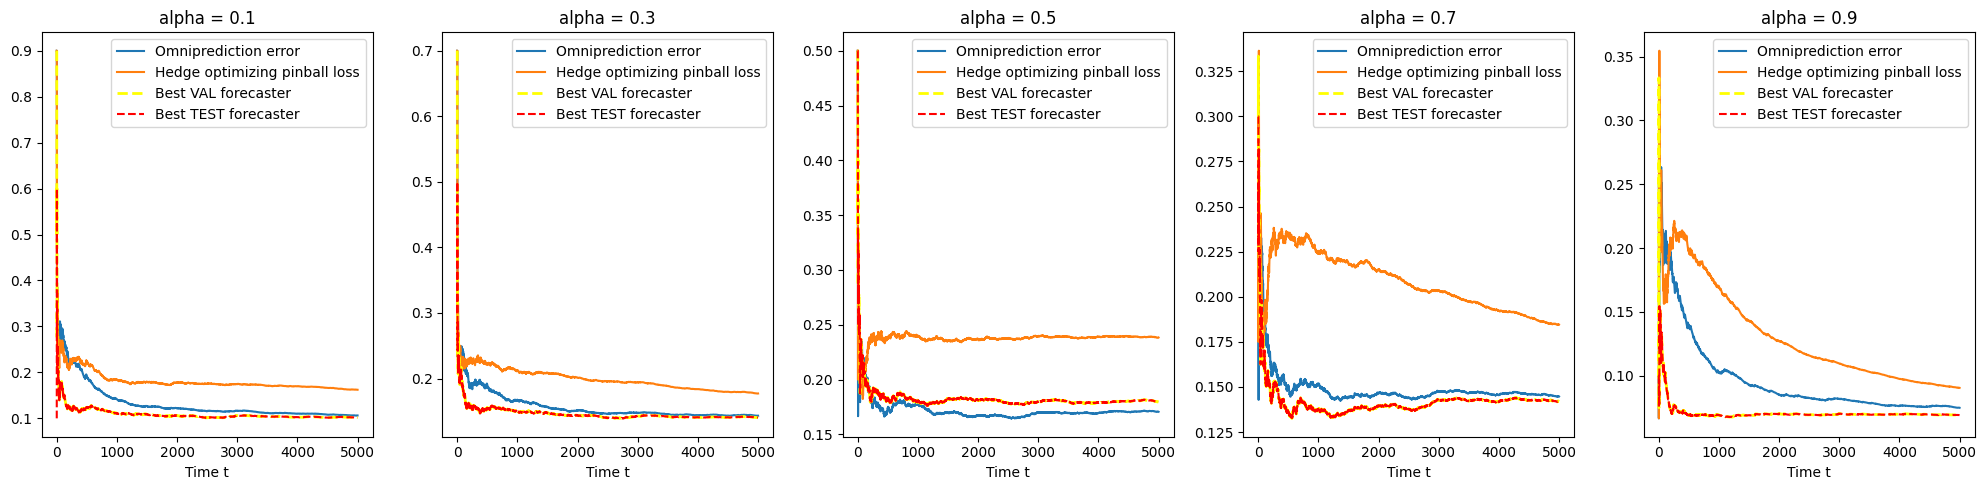

In [199]:
alpha_list = sorted(results_dic.keys())

fig, ax = plt.subplots(1, 5, figsize=(20, 5))

for ia, alpha in enumerate(alpha_list):
    results = results_dic[alpha]
    m = results['m']
    Y = results['Y']
    T = results['T']

    # Best Value
    forecasters_score_cumulative = results['forecasters_score_cumulative']
    best_val_forecaster = np.concatenate([[0], np.argmin(forecasters_score_cumulative, axis=1)[:-1]])
    best_val_forecaster_error = forecasters_score_cumulative[np.arange(T), best_val_forecaster]
    best_val_forecaster_preds = results['forecasters_preds_history'][np.arange(T), best_val_forecaster]

    best_test_forecaster = np.argmin(forecasters_score_cumulative, axis=1)
    best_test_forecaster_error = forecasters_score_cumulative[np.arange(T), best_test_forecaster]
    best_test_forecaster_preds = results['forecasters_preds_history'][np.arange(T), best_test_forecaster]

    # Pinball
    pinball_preds_history = results['pinball_preds_history']
    pinball_cum_error = np.max(np.array([single_q_omnipred_error(
                            predictions=pinball_preds_history[t],
                            Y=Y[t],
                            scoring_functions=create_scoring_function_class(alpha, m)[0],
                        ) for t in range(T)]).cumsum(axis=0) / (np.arange(T) + 1)[:, None], axis = 1)

    ax[ia].plot(np.arange(T), results['omni_score_trace'], label='Omniprediction error')
    ax[ia].plot(np.arange(T), pinball_cum_error, label='Hedge optimizing pinball loss')
    # ax[ia].plot(np.arange(T), [np.minimum(np.sqrt(np.log(m * F) / (t+1)), 1.0) for t in np.arange(T)], '--', label='Theoretical bound')

    ax[ia].plot(np.arange(T), best_val_forecaster_error, linewidth=2, color='yellow', linestyle='--', label='Best VAL forecaster')
    ax[ia].plot(np.arange(T), results['best_forecaster_score_trace'], color='red', linestyle='--', label='Best TEST forecaster')

    ax[ia].set_xlabel('Time t')
    ax[ia].legend()
    ax[ia].set_title(f'alpha = {alpha}')

fig.tight_layout()

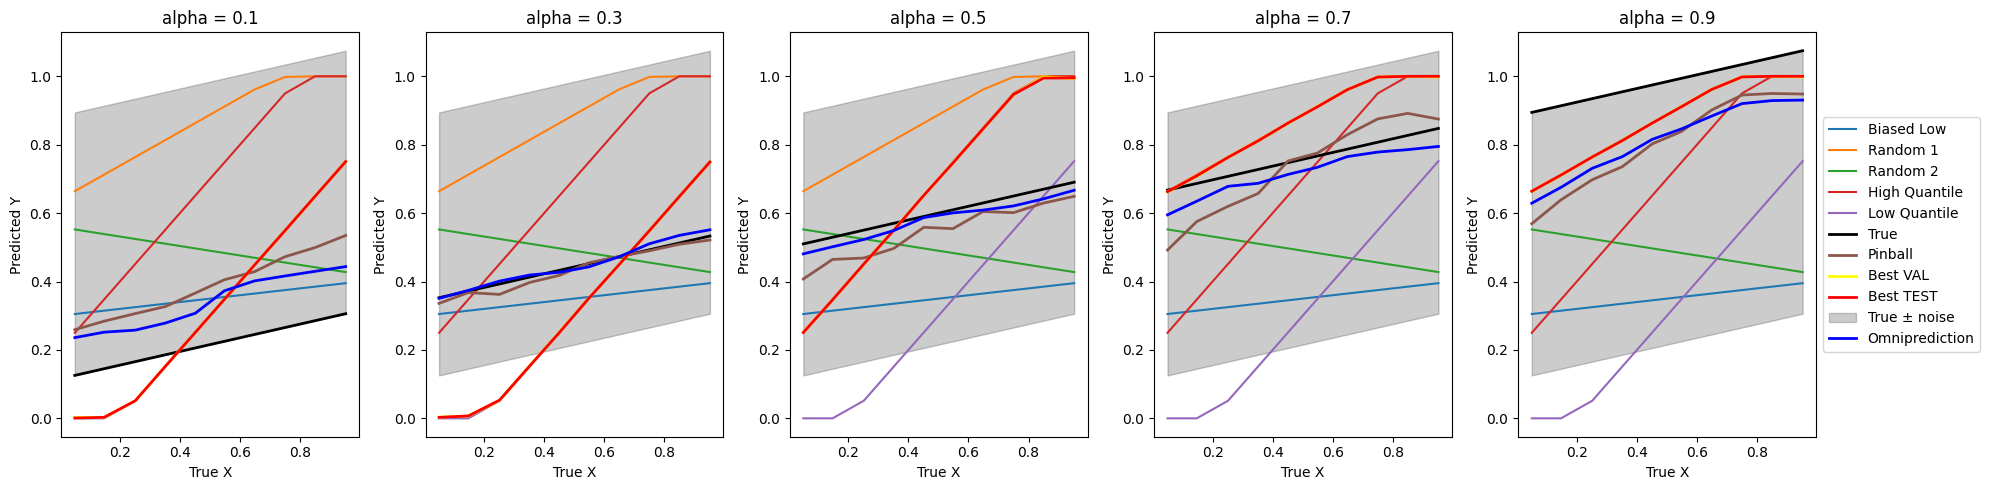

In [194]:
import pandas as pd
import scipy.stats as stats

fig, ax = plt.subplots(1, 5, figsize=(20, 5))
alpha_list = sorted(results_dic.keys())

for ia, alpha in enumerate(alpha_list):
    results = results_dic[alpha]
    X = results['X']    # (T, )
    Y = results['Y']    # (T, )
    phat_history = results['phat_history']    # (T,)
    preds_history = results['forecasters_preds_history']    # (T, F)
    pinball_preds_history = results['pinball_preds_history']

    # Best Value
    forecasters_score_cumulative = results['forecasters_score_cumulative']
    best_val_forecaster = np.concatenate([[0], np.argmin(forecasters_score_cumulative, axis=1)[:-1]])
    best_val_forecaster_error = forecasters_score_cumulative[np.arange(T), best_val_forecaster]
    best_val_forecaster_preds = results['forecasters_preds_history'][np.arange(T), best_val_forecaster]

    best_test_forecaster = np.argmin(forecasters_score_cumulative, axis=1)
    best_test_forecaster_error = forecasters_score_cumulative[np.arange(T), best_test_forecaster]
    best_test_forecaster_preds = results['forecasters_preds_history'][np.arange(T), best_test_forecaster]


    df = pd.DataFrame(np.concatenate([X[:, None],
                                    phat_history[:, None], 
                                    preds_history, 
                                    pinball_preds_history[:, None], 
                                    best_val_forecaster_preds[:, None], 
                                    best_test_forecaster_preds[:, None],
                                    Y[:, None]
                                    ], 
                                    axis=1
                                    ),
                                    columns=['X', 'phat', 'pred_1', 'pred_2', 'pred_3', 'pred_4', 'pred_5', 'pinball_pred', 'best_val_pred', 'best_test_pred', 'Y']
                                    )

    df['X_bin'] = pd.cut(df.iloc[:, 0], bins=10)
    binned_df = df.groupby('X_bin').mean(numeric_only=True)

    for j in range(F):
        ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, j+2], label=results['forecaster_names'][j])
    ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, 0] * 0.2 + 0.5 + 0.3*stats.norm.ppf(alpha), color='black', linewidth=2, label='True')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, F+2], linewidth=2, label='Pinball')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, F+3], color='yellow', linewidth=2, label='Best VAL')
    ax[ia].plot(binned_df.iloc[:, 0], binned_df.iloc[:, F+4], color='red', linewidth=2, label='Best TEST')
    #ax[ia].plot(binned_df.iloc[:, 0], df.groupby('X_bin')['Y'].quantile(alpha), color='green', linewidth=2, label='Y')
    ax[ia].errorbar(binned_df.iloc[:, 0], binned_df.iloc[:, 1], color='blue', linewidth=2, label='Omniprediction')
    ax[ia].fill_between(
        binned_df.iloc[:, 0],
        binned_df.iloc[:, 0] * 0.2 + 0.5 - 0.3*stats.norm.ppf(0.1),
        binned_df.iloc[:, 0] * 0.2 + 0.5 + 0.3*stats.norm.ppf(0.1),
        color='black',
        alpha=0.2,
        label='True ± noise'
    )
    ax[ia].set_xlabel('True X')
    ax[ia].set_ylabel('Predicted Y')
    ax[ia].set_title(f'alpha = {alpha}')
    if ia == len(alpha_list) - 1:
        ax[ia].legend(loc='center left', bbox_to_anchor=(1, 0.5))
fig.tight_layout()
plt.show()
    


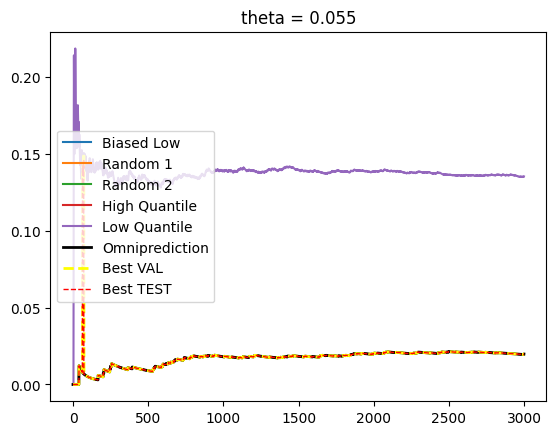

In [163]:
score_cum_avg = results['forecasters_score_history'].cumsum(axis=0) / (np.arange(len(results['forecasters_score_history']))[:, None, None] + 1)
results['omni_error_history']

lv = 5
for j in range(F):
    plt.plot(score_cum_avg[:,lv,j], label=results['forecaster_names'][j])
plt.plot(results['omni_error_history'][:,lv].cumsum() / (np.arange(len(results['omni_error_history'])) + 1), color='black', linewidth=2, label='Omniprediction')
plt.plot(score_cum_avg[np.arange(T), lv, best_val_forecaster], color='yellow', linestyle='--', linewidth=2, label='Best VAL')
plt.plot(score_cum_avg[np.arange(T), lv, best_test_forecaster], color='red', linestyle='--', linewidth=1, label='Best TEST')

plt.legend()
plt.title(f'theta = {1/(2*m) + lv/m}')
plt.show()

